In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
username = "elysia_"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [3]:
sql = """
    SELECT datadate, revt, ni, at, lt, prcc_f
    FROM comp.funda
    WHERE tic = 'AAPL'
      AND datadate >= '2019-01-01'
      AND datadate <= '2023-12-31'
    ORDER BY datadate;
"""

In [4]:
df = db.raw_sql(sql)

In [5]:
df = df.dropna()
df['datadate'] = pd.to_datetime(df['datadate'])
df['year'] = df['datadate'].dt.year

In [6]:
df['ROE'] = df['ni'] / (df['at'] - df['lt'])
df['Profit_Margin'] = df['ni'] / df['revt']

In [7]:
print("Apple 2019–2023 财务数据")
print(df[['year','revt','ni','ROE','Profit_Margin']])

Apple 2019–2023 财务数据
   year      revt       ni       ROE  Profit_Margin
0  2019  260174.0  55256.0  0.610645       0.212381
2  2020  274515.0  57411.0  0.878664       0.209136
4  2021  365817.0  94680.0  1.500713       0.258818
6  2022  394328.0  99803.0  1.969589       0.253096
8  2023  383285.0  96995.0   1.56076       0.253062


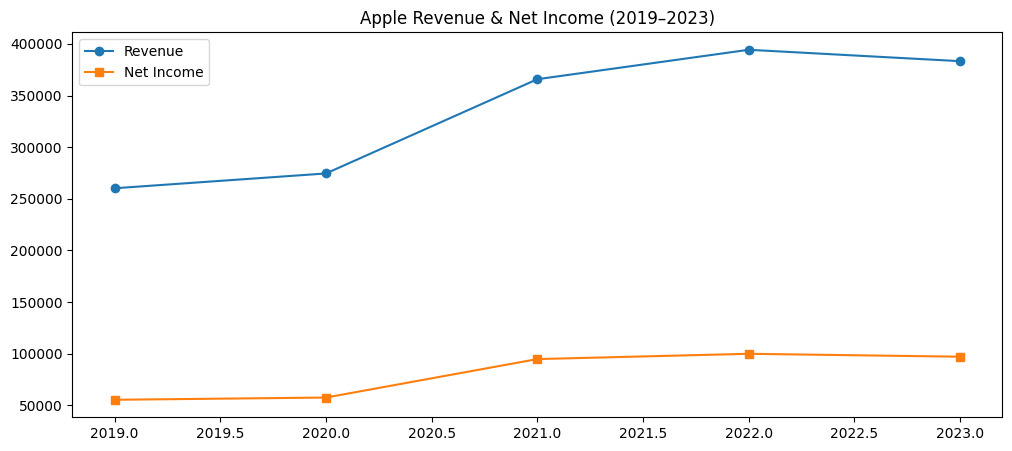

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['year'], df['revt'], marker='o', label='Revenue')
plt.plot(df['year'], df['ni'], marker='s', label='Net Income')
plt.title('Apple Revenue & Net Income (2019–2023)')
plt.legend()
plt.show()

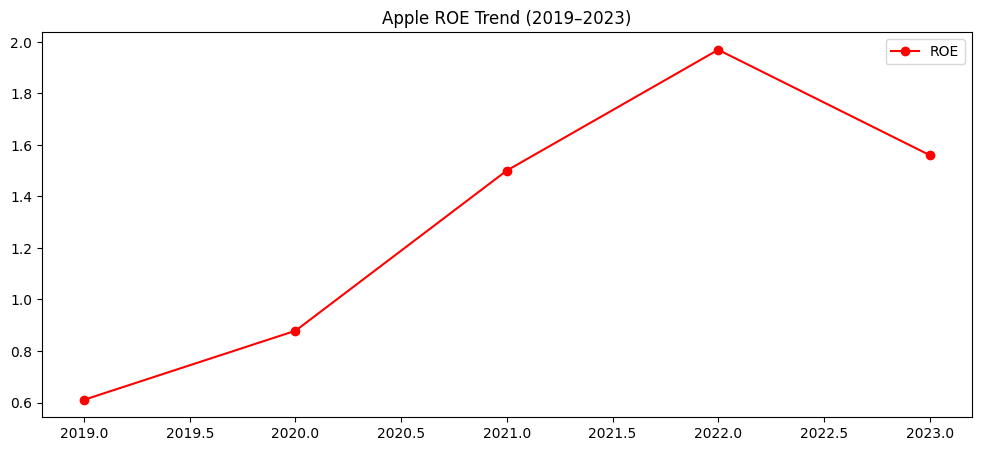

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df['year'], df['ROE'], marker='o', color='red', label='ROE')
plt.title('Apple ROE Trend (2019–2023)')
plt.legend()
plt.show()

In [10]:
db.close()